## Preprocessing

In [2]:
import pandas as pd
import numpy as np

In [56]:
cols = ['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min',
 'Label']

In [64]:
# df1 = pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", nrows=1000000, skiprows=50000000, names=cols)

In [66]:
chunks = []
chunk_size = 50000

for chunk in pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", chunksize=chunk_size):
    chunk_ = chunk.sample(frac=0.05, random_state=42)
    chunks.append(chunk_)

In [67]:
df = pd.concat(chunks, ignore_index=True)

In [71]:
df["Label"].value_counts()

Label
ddos      323647
Benign    316084
Name: count, dtype: int64

In [72]:
df.to_csv('/kaggle/working/sample_data.csv', index=False)

In [73]:
df.head()

,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,150754,192.168.56.1-97.74.144.108-36855-80-6,192.168.56.1,36855,97.74.144.108,80,6,13/06/2010 12:23:17 AM,26545238,5,...,0,4331.333333,7495.161795,12986.0,1.0,8843684.0,1.191166e+06,10186083.0,7912967.0,ddos
1,49247,192.168.56.1-67.220.214.50-36818-80-6,192.168.56.1,36818,67.220.214.50,80,6,12/06/2010 02:36:17 PM,24975333,5,...,0,4255.000000,7358.617873,12752.0,6.0,8320671.0,2.212232e+06,10186104.0,5876634.0,ddos
2,1638,192.168.2.108-74.55.1.4-1253-80-6,192.168.2.108,1253,74.55.1.4,80,6,12/06/2010 08:47:02 AM,5030987,1,...,0,0.000000,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,ddos
3,54404,192.168.2.109-203.73.24.75-1555-80-6,192.168.2.109,1555,203.73.24.75,80,6,12/06/2010 02:45:57 PM,303,2,...,0,0.000000,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,ddos
4,199244,192.168.2.109-203.73.24.75-4227-80-6,192.168.2.109,4227,203.73.24.75,80,6,13/06/2010 07:38:02 AM,292,2,...,0,0.000000,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,ddos


In [74]:
df.columns.tolist()

['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pk

In [75]:
df.drop(columns=["Unnamed: 0", "Flow ID", "Timestamp", "Src IP", "Dst IP"], inplace=True)

In [76]:
columns_with_nan = df.columns[df.isnull().any()]

for col in columns_with_nan:
    print(f"Column '{col}' has {df[col].isnull().sum()} NaN values")

Column 'Flow Byts/s' has 1454 NaN values


In [33]:
# columns_with_inf = df1.columns[np.isinf(train_X).any()]

# for col in columns_with_inf:
#     print(f"Column '{col}' has {df1[col].isnull().sum()} INF values")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 80 but corresponding boolean dimension is 79

In [77]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [78]:
df = pd.DataFrame(df.dropna(), columns=df.columns)

In [79]:
y = df["Label"]
X = df.drop(columns=["Label"])

In [47]:
y.nunique()

1

In [80]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [81]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [82]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

In [83]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_X)
train_X = pd.DataFrame(train_scaled, columns=train_X.columns, index=train_X.index)

In [84]:
test_X = pd.DataFrame(scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

In [85]:
train_X.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0.006790,0.957137,0.352941,2.000000e-07,0.000009,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.454545,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.820539,0.006760,0.352941,9.776659e-01,0.000077,0.000058,0.000219,0.000011,0.025813,0.0,...,0.000045,0.454545,0.000624,0.00014,0.000687,0.000560,0.488126,0.007722,0.491547,0.484705
2,0.647959,0.001221,0.352941,4.355417e-04,0.000009,0.000003,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.652323,0.001221,0.352941,3.567084e-04,0.000005,0.000003,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.767010,0.001221,0.352941,6.161862e-01,0.000050,0.000041,0.000076,0.000003,0.018450,0.0,...,0.000045,0.454545,0.000373,0.00014,0.000564,0.000278,0.083712,0.000787,0.084784,0.083379


In [87]:
train_y = train_y.map({"Benign": 0, "ddos": 1})

In [90]:
test_y = test_y.map({"Benign": 0, "ddos": 1})

## Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_X, train_y.reset_index(drop=True))

LogisticRegression(max_iter=1000, random_state=42)

In [115]:
y_pred = model.predict(test_X)

In [102]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [95]:
train_X.shape, test_X.shape

((509895, 79), (127474, 79))

In [117]:
print("Accuracy:", accuracy_score(test_y.reset_index(drop=True), y_pred))
print("\nClassification Report:\n", classification_report(test_y, y_pred))


Accuracy: 0.9827258892009351

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     62742
           1       0.98      0.98      0.98     64732

    accuracy                           0.98    127474
   macro avg       0.98      0.98      0.98    127474
weighted avg       0.98      0.98      0.98    127474



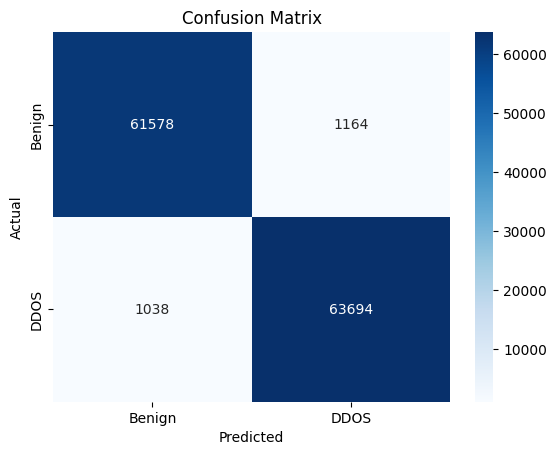

In [119]:
conf_matrix = confusion_matrix(test_y.reset_index(drop=True), y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

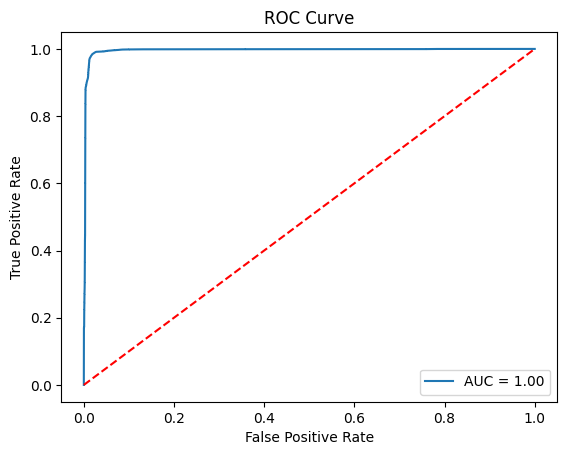

In [121]:
y_pred_proba = model.predict_proba(test_X)[:,1]
fpr, tpr, _ = roc_curve(test_y.reset_index(drop=True), y_pred_proba)
auc = roc_auc_score(test_y.reset_index(drop=True), y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [104]:
import joblib
joblib.dump(model, '/kaggle/working/log_reg_model.pkl')

['/kaggle/working/log_reg_model.pkl']

# Autoencoder

In [122]:
train_X.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0.006790,0.957137,0.352941,2.000000e-07,0.000009,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.454545,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.820539,0.006760,0.352941,9.776659e-01,0.000077,0.000058,0.000219,0.000011,0.025813,0.0,...,0.000045,0.454545,0.000624,0.00014,0.000687,0.000560,0.488126,0.007722,0.491547,0.484705
2,0.647959,0.001221,0.352941,4.355417e-04,0.000009,0.000003,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.652323,0.001221,0.352941,3.567084e-04,0.000005,0.000003,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.767010,0.001221,0.352941,6.161862e-01,0.000050,0.000041,0.000076,0.000003,0.018450,0.0,...,0.000045,0.454545,0.000373,0.00014,0.000564,0.000278,0.083712,0.000787,0.084784,0.083379


In [129]:
train_y.reset_index(drop=True).head()
pd.DataFrame(train_y).head()

,Label
357423,0
524405,0
173365,1
233179,1
458721,0


In [135]:
train_X_benign = train_X[pd.DataFrame(train_y).reset_index(drop=True)["Label"]==0].reset_index(drop=True)

In [136]:
train_X_benign.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0.006790,0.957137,0.352941,2.000000e-07,0.000009,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.454545,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,0.820539,0.006760,0.352941,9.776659e-01,0.000077,0.000058,0.000219,1.097104e-05,0.025813,0.000000,...,0.000045,0.454545,0.000624,0.00014,0.000687,0.000560,0.488126,7.722296e-03,0.491547,0.484705
2,0.767010,0.001221,0.352941,6.161862e-01,0.000050,0.000041,0.000076,2.700424e-06,0.018450,0.000000,...,0.000045,0.454545,0.000373,0.00014,0.000564,0.000278,0.083712,7.872184e-04,0.084784,0.083379
3,0.000000,0.000000,0.000000,9.386535e-01,0.000014,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.469498,1.035088e-07,0.469498,0.469497
4,0.980911,0.000809,1.000000,2.202084e-04,0.000009,0.000007,0.000015,1.769769e-07,0.001798,0.028533,...,0.000006,0.181818,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000


In [123]:
import torch
import torch.nn as nn
import torch.optim as optim

In [155]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim): # x -> x' -> x'' 
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 8),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.SELU(),
            nn.Linear(32, 64),
            nn.SELU(),
            nn.Linear(64, input_dim),
            nn.SELU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [156]:
input_dim = train_X_benign.shape[1]
model = Autoencoder(input_dim)
criterion = nn.L1Loss()
optimizer = optim.RMSprop(model.parameters(), lr=0.0001)

In [143]:
# train_X_backup = train_X.copy()
# test_X_backup = test_X.copy()
# train_y_backup = train_y.copy()
# test_y_backup = test_y.copy()
# train_X_benign_backup = train_X_benign.copy()

# train_X = train_X_backup.copy()
# test_X = test_X_backup.copy()
# train_y = train_y_backup.copy()
# test_y = test_y_backup.copy()
# train_X_benign = train_X_benign_backup.copy()

In [165]:
# train_X = torch.FloatTensor(train_X.values)
# train_y = torch.LongTensor(train_y.values)
# test_X = torch.FloatTensor(test_X.values)
# test_y = torch.LongTensor(test_y.values)
# train_X_benign = torch.FloatTensor(train_X_benign.values)

TypeError: new(): data must be a sequence (got builtin_function_or_method)

In [161]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X_benign), batch_size=32, shuffle=True)
epochs = 20

In [162]:
epoch_losses = []
reconstruction_losses_last_epoch = [] 
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()

        # Track individual sample reconstruction losses only in the last epoch
        if epoch == epochs - 1:  # Collect only for the last epoch
            reconstruction_losses_last_epoch.extend(loss.item() for _ in range(len(inputs)))
            
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
    

Epoch 1/20, Loss: 0.0113
Epoch 2/20, Loss: 0.0112
Epoch 3/20, Loss: 0.0111
Epoch 4/20, Loss: 0.0110
Epoch 5/20, Loss: 0.0109
Epoch 6/20, Loss: 0.0108
Epoch 7/20, Loss: 0.0107
Epoch 8/20, Loss: 0.0106
Epoch 9/20, Loss: 0.0106
Epoch 10/20, Loss: 0.0105
Epoch 11/20, Loss: 0.0104
Epoch 12/20, Loss: 0.0102
Epoch 13/20, Loss: 0.0101
Epoch 14/20, Loss: 0.0100
Epoch 15/20, Loss: 0.0099
Epoch 16/20, Loss: 0.0098
Epoch 17/20, Loss: 0.0097
Epoch 18/20, Loss: 0.0097
Epoch 19/20, Loss: 0.0096
Epoch 20/20, Loss: 0.0096


In [164]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

reconstruction_losses_last_epoch = np.array(reconstruction_losses_last_epoch)

mean_loss = np.mean(reconstruction_losses_last_epoch)
std_loss = np.std(reconstruction_losses_last_epoch)

threshold = mean_loss + 2 * std_loss 

print(f"Anomaly Detection Threshold: {threshold}")

Anomaly Detection Threshold: 0.014048626012801688


In [167]:
model.eval()
reconstruction_errors = []
test_labels = test_y.numpy()

with torch.no_grad():
    outputs = model(test_X)
    reconstruction_errors = torch.mean(torch.abs(outputs - test_X), dim=1).numpy()

predicted_labels = (reconstruction_errors > threshold).astype(int)

In [169]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [170]:
accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels)
recall = recall_score(test_labels, predicted_labels)
f1 = f1_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8540
Precision: 0.7985
Recall: 0.9530
F1 Score: 0.8690


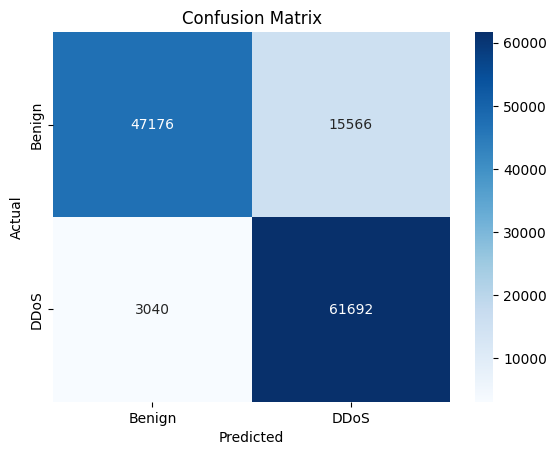

In [173]:
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [171]:
torch.save(model, "/kaggle/working/autoencoder.pt")